# 🛍️ Customer Segmentation Analysis using K-Means Clustering

### Oasis Infobyte Data Analytics Internship (OIBSIP)

**Track:** Data Analytics

**Level:** 1

**Task:** 2 – Customer Segmentation Analysis

**Author:** Moubani

---

## 📌 Objective

The objective of this project is to apply the K-Means clustering algorithm to segment customers based on their purchasing behaviour. Using Recency, Frequency, and Monetary (RFM) analysis, customers are grouped into meaningful segments that can help businesses design targeted marketing strategies, improve customer retention, and maximize revenue.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [16]:
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\n")
print("="*50)
print("FIRST FIVE ROWS")
print("="*50)
display(df.head())

print("\n")
print("="*50)
print("COLUMN INFORMATION")
print("="*50)
print(df.info())

print("\n")
print("="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n")
print("="*50)
print("DUPLICATE ROWS")
print("="*50)
print(df.duplicated().sum())

DATASET SHAPE
(541909, 8)


FIRST FIVE ROWS


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom




COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


MISSING VALUES
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


DUPLICATE ROWS
5268


### 📌 Observation

- The Online Retail dataset contains transaction-level records of customer purchases.
- Initial inspection provides information about the dataset size, column names, data types, missing values, and duplicate records.
- Missing values are mainly observed in the **CustomerID** and **Description** columns, while duplicate records are also present.
- These issues will be addressed during the data cleaning stage to ensure accurate customer segmentation.

In [17]:
print("Original Dataset Shape:", df.shape)

df = df.dropna(subset=["CustomerID"])
df = df.drop_duplicates()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("\nCleaned Dataset Shape:", df.shape)
print("\nRemaining Missing Values")
print(df.isnull().sum())

Original Dataset Shape: (541909, 8)

Cleaned Dataset Shape: (392692, 8)

Remaining Missing Values
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


### 📌 Observation

- Missing customer IDs were removed because customer identification is essential for segmentation.
- Duplicate records were eliminated to avoid biased customer behaviour analysis.
- Transactions with negative quantities or zero prices were excluded as they represent cancellations or invalid purchases.
- After cleaning, the dataset is ready for feature engineering and clustering analysis.

In [18]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
print("First Five Records")

display(df.head())

print("\nDataset Shape:", df.shape)
print("\nTransaction Value Summary")
print(df["TotalAmount"].describe())
print("\n✅ Feature engineering completed successfully!")

First Five Records


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34



Dataset Shape: (392692, 9)

Transaction Value Summary
count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

✅ Feature engineering completed successfully!


### 📌 Observation

- A new feature named **TotalAmount** was created by multiplying **Quantity** and **UnitPrice**.
- The average transaction value is **22.63**, while the median is **12.45**, indicating that a few high-value purchases increase the overall average.
- This feature will be used to measure customer spending behaviour and calculate Customer Lifetime Value (CLV).

In [19]:
customer_stats = df.groupby("CustomerID").agg(
    Average_Purchase_Value=("TotalAmount", "mean"),
    Purchase_Frequency=("InvoiceNo", "nunique"),
    Customer_Lifetime_Value=("TotalAmount", "sum")
)

print("First Five Customers")
display(customer_stats.head())
print("\nDescriptive Statistics")
display(customer_stats.describe())

print("\n✅ Customer statistics calculated successfully!")

First Five Customers


,Average_Purchase_Value,Purchase_Frequency,Customer_Lifetime_Value
CustomerID,,,
12346,77183.600000,1,77183.60
12347,23.681319,7,4310.00
12348,57.975484,4,1797.24
12349,24.076027,1,1757.55
12350,19.670588,1,334.40



Descriptive Statistics


,Average_Purchase_Value,Purchase_Frequency,Customer_Lifetime_Value
count,4338.000000,4338.000000,4338.000000
mean,68.381590,4.272015,2048.688081
std,1467.918294,7.697998,8985.230220
min,2.136970,1.000000,3.750000
25%,12.393196,1.000000,306.482500
50%,17.755000,2.000000,668.570000
75%,24.878950,5.000000,1660.597500
max,77183.600000,209.000000,280206.020000



✅ Customer statistics calculated successfully!


### 📌 Observation

- Customer-level purchasing behaviour was summarized using three important metrics:
  - **Average Purchase Value**
  - **Purchase Frequency**
  - **Customer Lifetime Value (CLV)**
- The dataset contains **4,338 unique customers**.
- While the average customer spends approximately **2048.69** over their lifetime, a few customers contribute exceptionally high revenue, indicating significant variation in customer value.
- These metrics provide a strong foundation for customer segmentation and targeted marketing strategies.

In [20]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
)

print("RFM Table")
display(rfm.head())

print("\nRFM Summary Statistics")
display(rfm.describe())

print("\nDataset Shape:", rfm.shape)
print("\n✅ RFM features created successfully!")

RFM Table


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40



RFM Summary Statistics


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000



Dataset Shape: (4338, 3)

✅ RFM features created successfully!


### 📌 Observation

- Three behavioural features were created using **RFM Analysis**:
  - **Recency:** Number of days since the customer's last purchase.
  - **Frequency:** Number of unique purchases made by each customer.
  - **Monetary:** Total amount spent by each customer.
- These features capture customer purchasing behaviour and are widely used for customer segmentation in retail analytics.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
print("Scaled Data Shape:", rfm_scaled.shape)

print("\nFirst Five Scaled Records:")
print(pd.DataFrame(rfm_scaled,
                   columns=rfm.columns,
                   index=rfm.index).head())

print("\n✅ Data standardization completed successfully!")

Scaled Data Shape: (4338, 3)

First Five Scaled Records:
             Recency  Frequency  Monetary
CustomerID                               
12346       2.334574  -0.425097  8.363010
12347      -0.905340   0.354417  0.251699
12348      -0.175360  -0.035340 -0.027988
12349      -0.735345  -0.425097 -0.032406
12350       2.174578  -0.425097 -0.190812

✅ Data standardization completed successfully!


### 📌 Observation

- The RFM features were standardized using **StandardScaler**.
- Standardization ensures that all features contribute equally during clustering, preventing variables with larger numerical ranges from dominating the model.
- The standardized dataset is now ready for K-Means clustering.

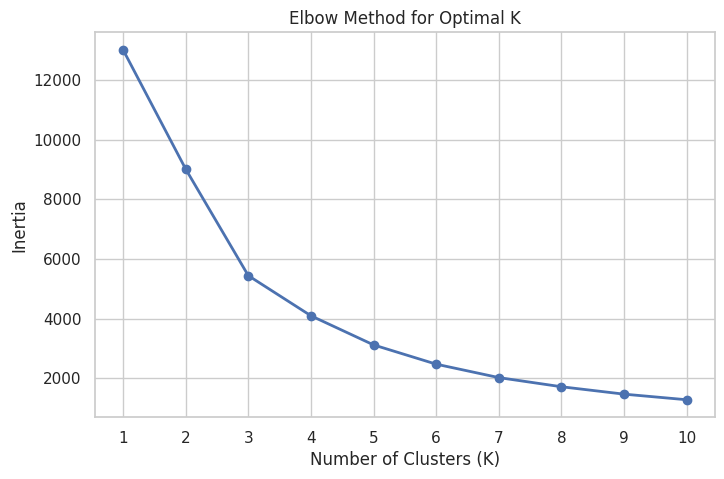

✅ Elbow Method completed successfully!


In [22]:
inertia = []
K = range(1, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia,
         marker='o',
         linewidth=2)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K)
plt.grid(True)
plt.show()

print("✅ Elbow Method completed successfully!")

### 📌 Observation
The Elbow Method was used to determine the optimal number of clusters for K-Means clustering. The inertia (WCSS) decreases sharply from K = 1 to K = 3, after which the rate of decrease becomes much slower, forming an "elbow" at K = 3. Therefore, 3 is selected as the optimal number of clusters, as it provides a good balance between minimizing within-cluster variation and avoiding unnecessary complexity.

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print("Cluster Distribution:")
print(rfm['Cluster'].value_counts())
print("\nFirst Five Customers with Cluster Labels")
rfm.head()

Cluster Distribution:
Cluster
1    3230
0    1082
2      26
Name: count, dtype: int64

First Five Customers with Cluster Labels


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,0
12347,2,7,4310.00,1
12348,75,4,1797.24,1
12349,19,1,1757.55,1
12350,310,1,334.40,0


### 📌 Observation

- K-Means successfully assigned every customer to a cluster.
- Customers within the same cluster exhibit similar purchasing behaviour based on Recency, Frequency, and Monetary values.
- These clusters will now be analysed and visualised to understand different customer segments.

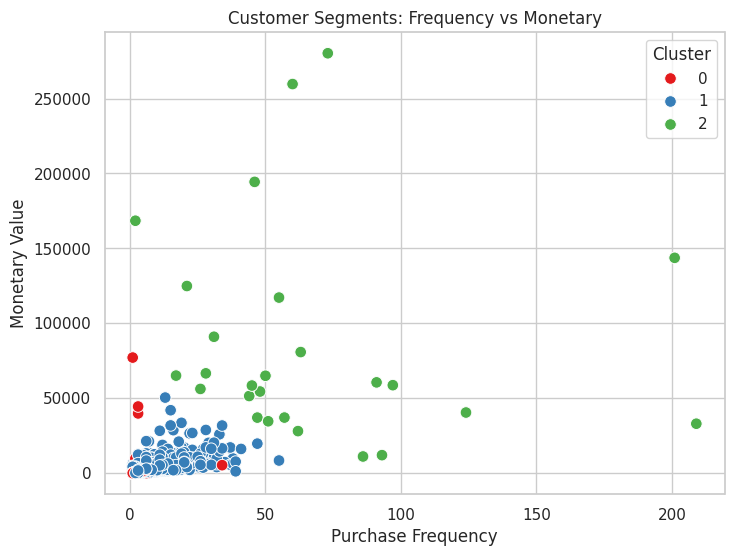

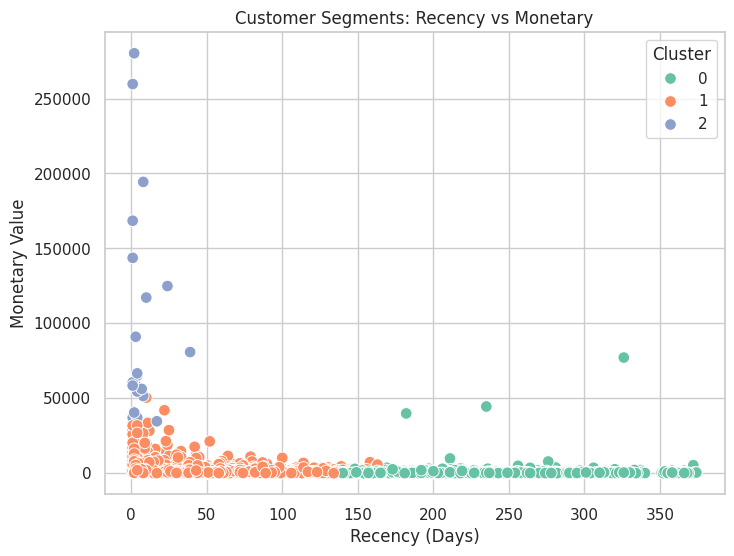

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=70
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.show()
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.show()

### 📌 Observation

- Two scatter plots were used to visualize the customer segments formed by the K-Means algorithm.
- The **Frequency vs Monetary** plot shows that customers with higher purchase frequency generally generate higher revenue.
- The **Recency vs Monetary** plot indicates that recently active customers (low Recency) tend to have higher monetary value, while customers with high Recency are generally less valuable.
- Three distinct customer groups are visible:
  - **Cluster 0:** Inactive or at-risk customers with high recency and comparatively low spending.
  - **Cluster 1:** Regular customers with moderate purchasing behaviour.
  - **Cluster 2:** High-value (VIP) customers with very high spending and recent purchase activity.
- These customer segments can be used to design personalized marketing campaigns and improve customer retention.

In [25]:
cluster_profile = rfm.groupby("Cluster").mean().round(2)

print("Cluster Profile:")
display(cluster_profile)

Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,247.11,1.58,629.66
1,41.45,4.67,1849.67
2,6.04,66.42,85826.08


### 📌 Observation:

The mean values of Recency, Frequency, and Monetary were calculated for each customer cluster to understand customer purchasing behavior.

• Cluster 0 consists of inactive customers with the highest average Recency (247.11 days), very low purchase frequency (1.58), and low spending (₹629.66). These customers have not purchased recently and are at risk of churn.

• Cluster 1 represents regular customers with moderate Recency (41.45 days), average purchase frequency (4.67), and moderate spending (₹1,849.67). This is the largest customer segment and includes active, repeat buyers.

• Cluster 2 contains a very small group of premium customers with the lowest Recency (6.04 days), the highest purchase frequency (66.42), and exceptionally high spending (₹85,826.08). These customers are the most valuable and contribute significantly to business revenue.

Overall, the clustering process successfully identified three distinct customer segments, enabling businesses to design personalized marketing strategies for each customer group.

Number of Customers in Each Cluster:
Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64


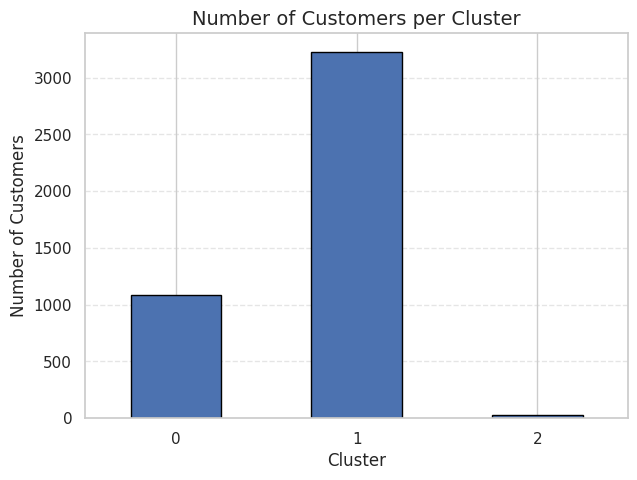


✅ Cluster distribution visualized successfully!


In [26]:
import matplotlib.pyplot as plt

cluster_counts = rfm['Cluster'].value_counts().sort_index()
print("Number of Customers in Each Cluster:")
print(cluster_counts)
plt.figure(figsize=(7,5))

cluster_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Number of Customers per Cluster", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("\n✅ Cluster distribution visualized successfully!")

### 📌 Observation:
The bar chart shows that Cluster 1 contains the largest number of customers (3,230), indicating that most customers belong to the regular customer segment. Cluster 0 has 1,082 customers, representing less active or inactive customers. Cluster 2 contains only 26 customers, making it the smallest but most valuable customer segment based on the cluster profile. This distribution suggests that while most customers are regular buyers, a small group of premium customers contributes significantly to revenue.

In [29]:
final_report = cluster_profile.copy().round(2)

final_report["Customer Type"] = [
    "Inactive / Low Value",
    "Regular Customers",
    "VIP Customers"
]

final_report["Marketing Recommendation"] = [
    "Re-engagement emails & discount coupons",
    "Loyalty rewards & cross-selling",
    "VIP membership & premium support"
]

final_report = final_report.reset_index()
print("========== CUSTOMER SEGMENTATION REPORT ==========\n")
display(final_report)

print("\nOverall Conclusion:")
print("- Cluster 0 consists of inactive customers who require re-engagement.")
print("- Cluster 1 represents the majority of regular customers and should be retained through loyalty programs.")
print("- Cluster 2 contains a small number of VIP customers who generate the highest revenue and deserve personalized services.")

print("\n✅ Customer segmentation analysis completed successfully!")

========== CUSTOMER SEGMENTATION REPORT ==========



,Cluster,Recency,Frequency,Monetary,Customer Type,Marketing Recommendation
0,0,247.11,1.58,629.66,Inactive / Low Value,Re-engagement emails & discount coupons
1,1,41.45,4.67,1849.67,Regular Customers,Loyalty rewards & cross-selling
2,2,6.04,66.42,85826.08,VIP Customers,VIP membership & premium support



Overall Conclusion:
- Cluster 0 consists of inactive customers who require re-engagement.
- Cluster 1 represents the majority of regular customers and should be retained through loyalty programs.
- Cluster 2 contains a small number of VIP customers who generate the highest revenue and deserve personalized services.

✅ Customer segmentation analysis completed successfully!


### 📌 Observation:

The K-Means clustering algorithm successfully segmented customers into three meaningful groups based on Recency, Frequency, and Monetary (RFM) values.

Most customers belong to the regular customer segment (Cluster 1), while Cluster 0 represents inactive customers with low purchasing activity. Although Cluster 2 contains only a small number of customers, they contribute the highest spending and should be prioritized with exclusive offers and personalized services. These insights can help businesses improve customer retention, optimize marketing campaigns, and increase overall revenue.